In [12]:
# Enable autoreload to pick up code changes
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd

# Add parent directory to path to import from src/
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.dirname(notebook_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Project root: {project_root}")

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Import data loader
from src.data_loader import load_calhoun_soil_moisture

# Import gradient-based sampling utilities
from src.gradient_based_sampling import (
    gradient_based_sampling,
    visualize_gradient_sampling,
    compute_gradient_weights
)

# Import training function
from src.train_loop import finetune_pinn

# Import visualization
from src.visualization import plot_comprehensive_results, plot_training_losses

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✓ Modules loaded successfully")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/jasonjing/Documents/smap/SMAP-Recharge-Flux
Using device: cpu
✓ Modules loaded successfully


## 2. Configuration

In [13]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Path to base checkpoint (from initial training)
BASE_CHECKPOINT = '../notebooks/checkpoints_train/checkpoint_final.pt'

# Network configurations (must match base training)
h_net_config = {'hidden_dim': 64, 'num_layers': 4}
zb_net_config = {'hidden_dim': 32, 'num_layers': 3}

# Data configuration - SELECT TIME PERIOD FOR FINE-TUNING
DATA_PATH = '../data/2017_HalfHourly_UTC_ForestSite1.xlsx'
START_DATE = '2017-05-01'  # Different from base training!
END_DATE = '2017-05-9'    # ~2 week period

# Initial water table depth estimate for new period
ZB_INITIAL = 1.5  # meters (adjust based on season/conditions)

print("Configuration:")
print(f"  Base checkpoint: {BASE_CHECKPOINT}")
print(f"  New data period: {START_DATE} to {END_DATE}")
print(f"  Initial water table: {ZB_INITIAL} m")
print(f"  Network: h_net {h_net_config}, zb_net {zb_net_config}")

Configuration:
  Base checkpoint: ../notebooks/checkpoints_train/checkpoint_final.pt
  New data period: 2017-05-01 to 2017-05-9
  Initial water table: 1.5 m
  Network: h_net {'hidden_dim': 64, 'num_layers': 4}, zb_net {'hidden_dim': 32, 'num_layers': 3}


## 3. Load and Prepare New Soil Moisture Data

In [14]:
# ============================================================================
# LOAD SOIL MOISTURE DATA FOR FINE-TUNING
# ============================================================================

print("="*70)
print("LOADING NEW SOIL MOISTURE DATA FOR FINE-TUNING")
print("="*70)

soil_data = load_calhoun_soil_moisture(
    filepath=DATA_PATH,
    interpolate=True,
    max_gap_hours=6,
    start_date=START_DATE,
    end_date=END_DATE,
    verbose=True
)

# Extract data
datetime_col = soil_data['datetime']
times_seconds = soil_data['times_seconds']
theta_2cm = soil_data['theta_2cm']
theta_15cm = soil_data['theta_15cm']
theta_30cm = soil_data['theta_30cm']
theta_40cm = soil_data['theta_40cm']
theta_60cm = soil_data['theta_60cm']
theta_80cm = soil_data['theta_80cm']

print("\n" + "="*70)
print("DATA LOADED SUCCESSFULLY")
print("="*70)
print(f"Time range: {datetime_col.iloc[0]} to {datetime_col.iloc[-1]}")
print(f"Duration: {times_seconds[-1]/86400:.2f} days")
print(f"Total points: {len(times_seconds)}")

LOADING NEW SOIL MOISTURE DATA FOR FINE-TUNING
LOADING CALHOUN SOIL MOISTURE DATA

Data loaded:
  Total records: 17521
  Time range: 2017-01-01 01:00:00 to 2018-01-01 00:00:00
  Duration: ~364 days
  Resolution: 30 minutes

REPLACING MISSING VALUE CODES (-9999) WITH NaN
Missing value codes replaced with NaN

Time period selection (date-based):
  Start date: 2017-05-01 00:00:00
  End date:   2017-05-09 00:00:00
  Selected:   385 points
  Date range: 2017-05-01 00:00:00 to 2017-05-09 00:00:00
  Duration:   8.0 days

Raw data quality (after replacing -9999 with NaN):
----------------------------------------------------------------------
2cm   :   385 valid,     0 NaN ( 0.00%), range=[0.1113, 0.1979]
15cm  :   385 valid,     0 NaN ( 0.00%), range=[0.1467, 0.2342]
30cm  :   385 valid,     0 NaN ( 0.00%), range=[0.1419, 0.2572]
40cm  :   385 valid,     0 NaN ( 0.00%), range=[0.1829, 0.2800]
60cm  :   385 valid,     0 NaN ( 0.00%), range=[0.2357, 0.3255]
80cm  :   385 valid,     0 NaN ( 0.00%

### Visualize New Data

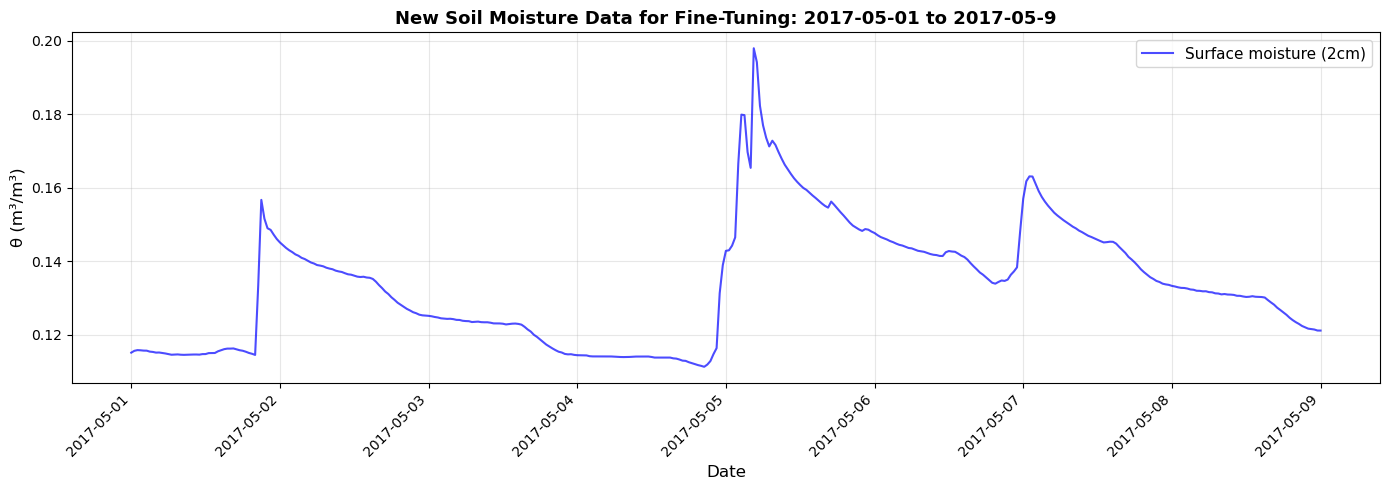


Surface Moisture Statistics:
  Valid points: 385 / 385
  Range: 0.1113 - 0.1979 m³/m³
  Mean: 0.1336 m³/m³
  Std: 0.0164 m³/m³


In [15]:
# ============================================================================
# VISUALIZE NEW SURFACE MOISTURE DATA
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(datetime_col, theta_2cm, 'b-', linewidth=1.5, alpha=0.7, label='Surface moisture (2cm)')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('θ (m³/m³)', fontsize=12)
ax.set_title(f'New Soil Moisture Data for Fine-Tuning: {START_DATE} to {END_DATE}', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Statistics
valid_mask = ~pd.isna(theta_2cm)
theta_valid = theta_2cm[valid_mask]
print(f"\nSurface Moisture Statistics:")
print(f"  Valid points: {valid_mask.sum()} / {len(theta_2cm)}")
print(f"  Range: {theta_valid.min():.4f} - {theta_valid.max():.4f} m³/m³")
print(f"  Mean: {theta_valid.mean():.4f} m³/m³")
print(f"  Std: {theta_valid.std():.4f} m³/m³")

### Prepare Boundary Condition Data

In [16]:
# ============================================================================
# PREPARE BOUNDARY CONDITION DATA (DIRICHLET BC)
# ============================================================================

# Remove NaN values from surface moisture
valid_mask = ~pd.isna(theta_2cm)
theta0_times = times_seconds[valid_mask]
theta0_values = theta_2cm[valid_mask]

# Convert to numpy arrays
theta0_times = np.array(theta0_times, dtype=np.float64)
theta0_values = np.array(theta0_values, dtype=np.float64)

# Create theta0_data tuple for training
new_theta0_data = (theta0_times, theta0_values)

print("="*70)
print("BOUNDARY CONDITION DATA PREPARED")
print("="*70)
print(f"BC Type: Dirichlet (prescribed moisture)")
print(f"  Surface BC: θ(z=0, t) = θ₀(t)")
print(f"  Data points: {len(new_theta0_data[0])}")
print(f"  Time range: {new_theta0_data[0][0]:.1f} - {new_theta0_data[0][-1]:.1f} s")
print(f"  Duration: {new_theta0_data[0][-1]/86400:.2f} days")
print(f"  Moisture range: {new_theta0_data[1].min():.4f} - {new_theta0_data[1].max():.4f} m³/m³")
print("="*70)

BOUNDARY CONDITION DATA PREPARED
BC Type: Dirichlet (prescribed moisture)
  Surface BC: θ(z=0, t) = θ₀(t)
  Data points: 385
  Time range: 0.0 - 691200.0 s
  Duration: 8.00 days
  Moisture range: 0.1113 - 0.1979 m³/m³



TESTING GRADIENT-BASED SAMPLING

Gradient Statistics:
  Max |dθ/dt|:  1.807e-05 m³/m³/s
  Mean |dθ/dt|: 5.161e-07 m³/m³/s
  Min |dθ/dt|:  0.000e+00 m³/m³/s

Generated 400 samples:
  Interpolated:  133 (33.2%)
  Neighbors:     66 (16.5%)
  Baseline:      201 (50.2%)


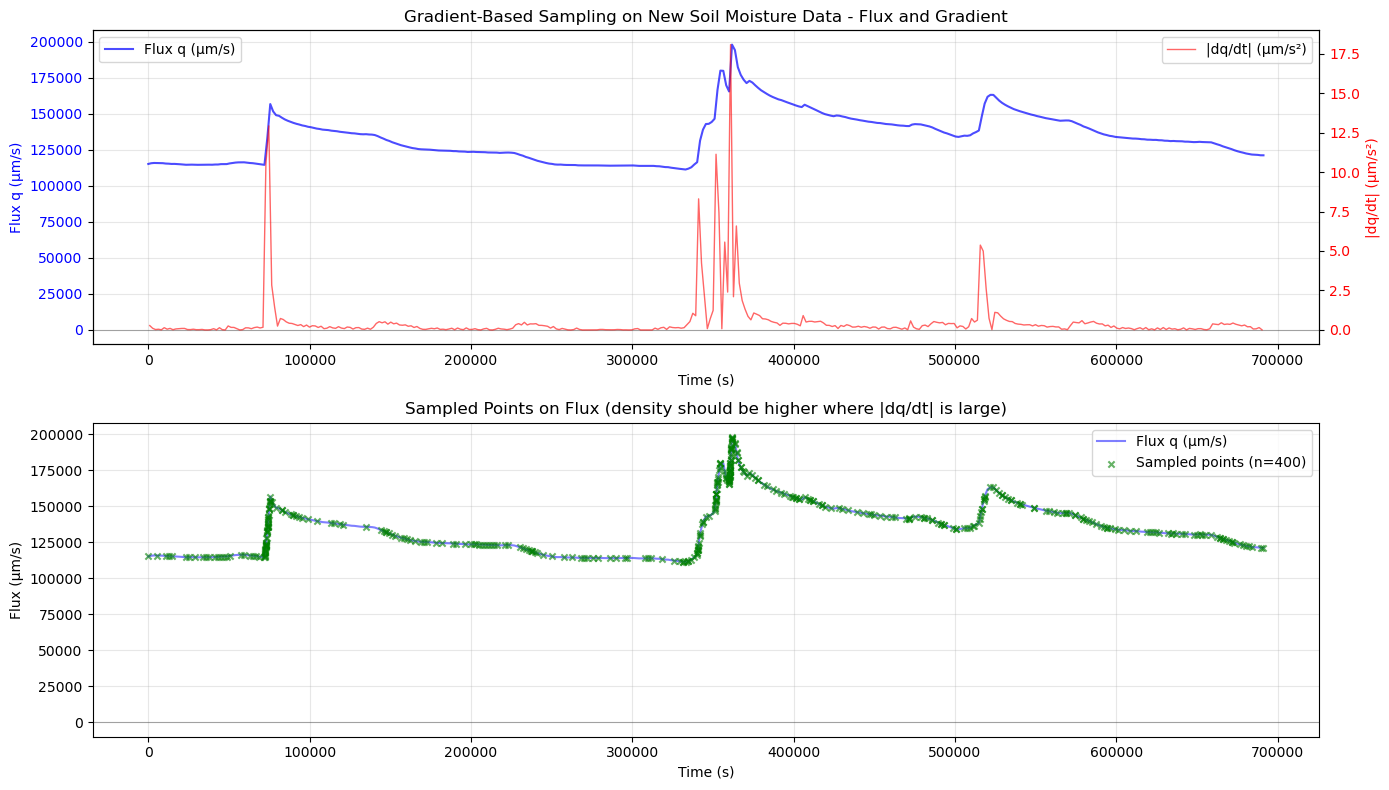

In [17]:
# ============================================================================
# TEST GRADIENT-BASED SAMPLING ON NEW DATA
# ============================================================================

print("\n" + "="*70)
print("TESTING GRADIENT-BASED SAMPLING")
print("="*70)

# Convert to tensors
theta0_times_t = torch.tensor(theta0_times, dtype=torch.float32).to(device)
theta0_values_t = torch.tensor(theta0_values, dtype=torch.float32).to(device)

# Compute gradients
gradient_weights, gradients = compute_gradient_weights(theta0_times_t, theta0_values_t, device)

print(f"\nGradient Statistics:")
print(f"  Max |dθ/dt|:  {gradients.abs().max().item():.3e} m³/m³/s")
print(f"  Mean |dθ/dt|: {gradients.abs().mean().item():.3e} m³/m³/s")
print(f"  Min |dθ/dt|:  {gradients.abs().min().item():.3e} m³/m³/s")

# Test sampling
t_bc_test, sample_info = gradient_based_sampling(
    theta0_times_t,
    theta0_values_t,
    batch_size_bc=400,
    device=device,
    use_interpolation=True,
    interp_ratio=0.10,
    neighbor_ratio=0.05,
    baseline_ratio=0.15,
    neighbor_expansion=2,
    gradient_threshold=0.7,
    power=2.0
)

print(f"\nGenerated {len(t_bc_test)} samples:")
print(f"  Interpolated:  {sample_info['n_interp_samples']} ({sample_info['actual_ratios']['interp']*100:.1f}%)")
print(f"  Neighbors:     {sample_info['n_neighbor_samples']} ({sample_info['actual_ratios']['neighbor']*100:.1f}%)")
print(f"  Baseline:      {sample_info['n_baseline_samples']} ({sample_info['actual_ratios']['baseline']*100:.1f}%)")

# Visualize
visualize_gradient_sampling(
    theta0_times_t,
    theta0_values_t,
    t_bc_test,
    sample_info,
    title='Gradient-Based Sampling on New Soil Moisture Data'
)
plt.show()

### Prepare Initial Condition Profile

In [18]:
# ============================================================================
# PREPARE INITIAL CONDITION FROM MEASURED PROFILE
# ============================================================================

ic_depths = []
ic_theta = []

depth_mapping = {
    '2cm': (0.02, theta_2cm),
    '15cm': (0.15, theta_15cm),
    '30cm': (0.30, theta_30cm),
    '40cm': (0.40, theta_40cm),
    '60cm': (0.60, theta_60cm),
    '80cm': (0.80, theta_80cm),
}

print("="*70)
print("CREATING INITIAL CONDITION FROM MEASURED PROFILE")
print("="*70)

for depth_name, (depth_m, theta_series) in depth_mapping.items():
    # Get first valid (non-NaN) value
    valid_mask = ~pd.isna(theta_series)
    if valid_mask.any():
        if isinstance(theta_series, pd.Series):
            theta_ic = theta_series[valid_mask].iloc[0]
        else:
            theta_ic = theta_series[valid_mask][0]
        ic_depths.append(depth_m)
        ic_theta.append(theta_ic)
        print(f"  {depth_name:6s}: θ = {theta_ic:.4f} m³/m³")

ic_profile = {
    'depths': ic_depths,  # meters below surface
    'theta': ic_theta     # volumetric water content
}

print(f"\nIC Profile: {len(ic_depths)} measurement points")
print("="*70)

CREATING INITIAL CONDITION FROM MEASURED PROFILE
  2cm   : θ = 0.1151 m³/m³
  15cm  : θ = 0.1484 m³/m³
  30cm  : θ = 0.1443 m³/m³
  40cm  : θ = 0.1848 m³/m³
  60cm  : θ = 0.2417 m³/m³
  80cm  : θ = 0.3637 m³/m³

IC Profile: 6 measurement points


## 4. Fine-Tune Model

In [19]:
# ============================================================================
# FINE-TUNE PINN WITH NEW MOISTURE DATA
# ============================================================================

print("\n" + "="*70)
print("STARTING FINE-TUNING")
print("="*70)

model, losses, comps, sample_losses, sample_comps, sample_epochs = finetune_pinn(
    checkpoint_path=BASE_CHECKPOINT,
    new_theta0_data=new_theta0_data,  # NEW moisture BC data
    zb_initial=ZB_INITIAL,
    h_net_config=h_net_config,
    zb_net_config=zb_net_config,

    # Fine-tuning hyperparameters (LOWER lr, FEWER epochs)
    n_epochs=10000,
    learning_rate=1e-4,  # 5x lower than base training (5e-4)

    # Sampling parameters
    cache_size=0,
    batch_size=1000,
    resample_freq=1000000,
    boundary_ratio=0.0,  # Uniform spatial sampling

    # Gradient-based boundary sampling
    batch_size_bc=450,
    interp_ratio=0.5,
    neighbor_ratio=0.0,
    baseline_ratio=0.5,
    gradient_neighbor_expansion=2,
    gradient_threshold=0.7,
    gradient_power=2.0,

    # Weight management (FIXED weights)
    weight_update_freq=1e10,  # No adaptive weight updates
    weight_lr=0.1,
    use_initial_scales=True,

    # Initial condition
    ic_profile=ic_profile,
    ic_type='obs',  # Use measured profile

    # Device and GPU settings
    device=device,
    use_multi_gpu=False,
    use_amp=False,
    grad_accumulation_steps=1,

    # Checkpointing (isolated from base training)
    checkpoint_dir='checkpoints_finetune',
    checkpoint_freq=2000,
    keep_last_n_checkpoints=3,
)

print("\n" + "="*70)
print("FINE-TUNING COMPLETE!")
print("="*70)


STARTING FINE-TUNING
Loading pretrained model from: ../notebooks/checkpoints_train/checkpoint_final.pt
Checkpoint loaded successfully
  Trained for 20000 epochs
  Normalization params: L=4.00, S_max=1.00e-07
  Network scaling: t_ref_tilde=8.31, z_max_tilde=1.00

NORMALIZATION SCALES
Length scale (L):           4.000 m
Head scale (H_*):           4.000 m
Conductivity scale (K_*):   1.00e-05 m/s
Flux scale (Q_*):           1.00e-05 m/s
Water content span (θ_*):   0.390
Time scale (T):             1.56e+05 s (43.33 hours)
Dimensionless α̃:            13.6000
Dimensionless S̃_max:        0.0400


Fine-Tuning Configuration
Base checkpoint: ../notebooks/checkpoints_train/checkpoint_final.pt
Base training epochs: 20000

Preserved normalization parameters:
  soil_params: θs=0.4, θr=0.01, α=3.4, n=1.7
  L=4.00 m, S_max=1.00e-07 1/s
  Sy=0.3, zr=0.50 m

Preserved network scaling:
  t_ref_tilde=8.3077 (FIXED reference time from base model)
  t_ref_days=15.00 days
  z_max_tilde=1.0000

New bounda

SOIL PARAMETERS (from base checkpoint):
  theta_s: 0.4
  theta_r: 0.01
  alpha: 3.4
  n: 1.7
  Ks: 1e-05
  l: 0.5


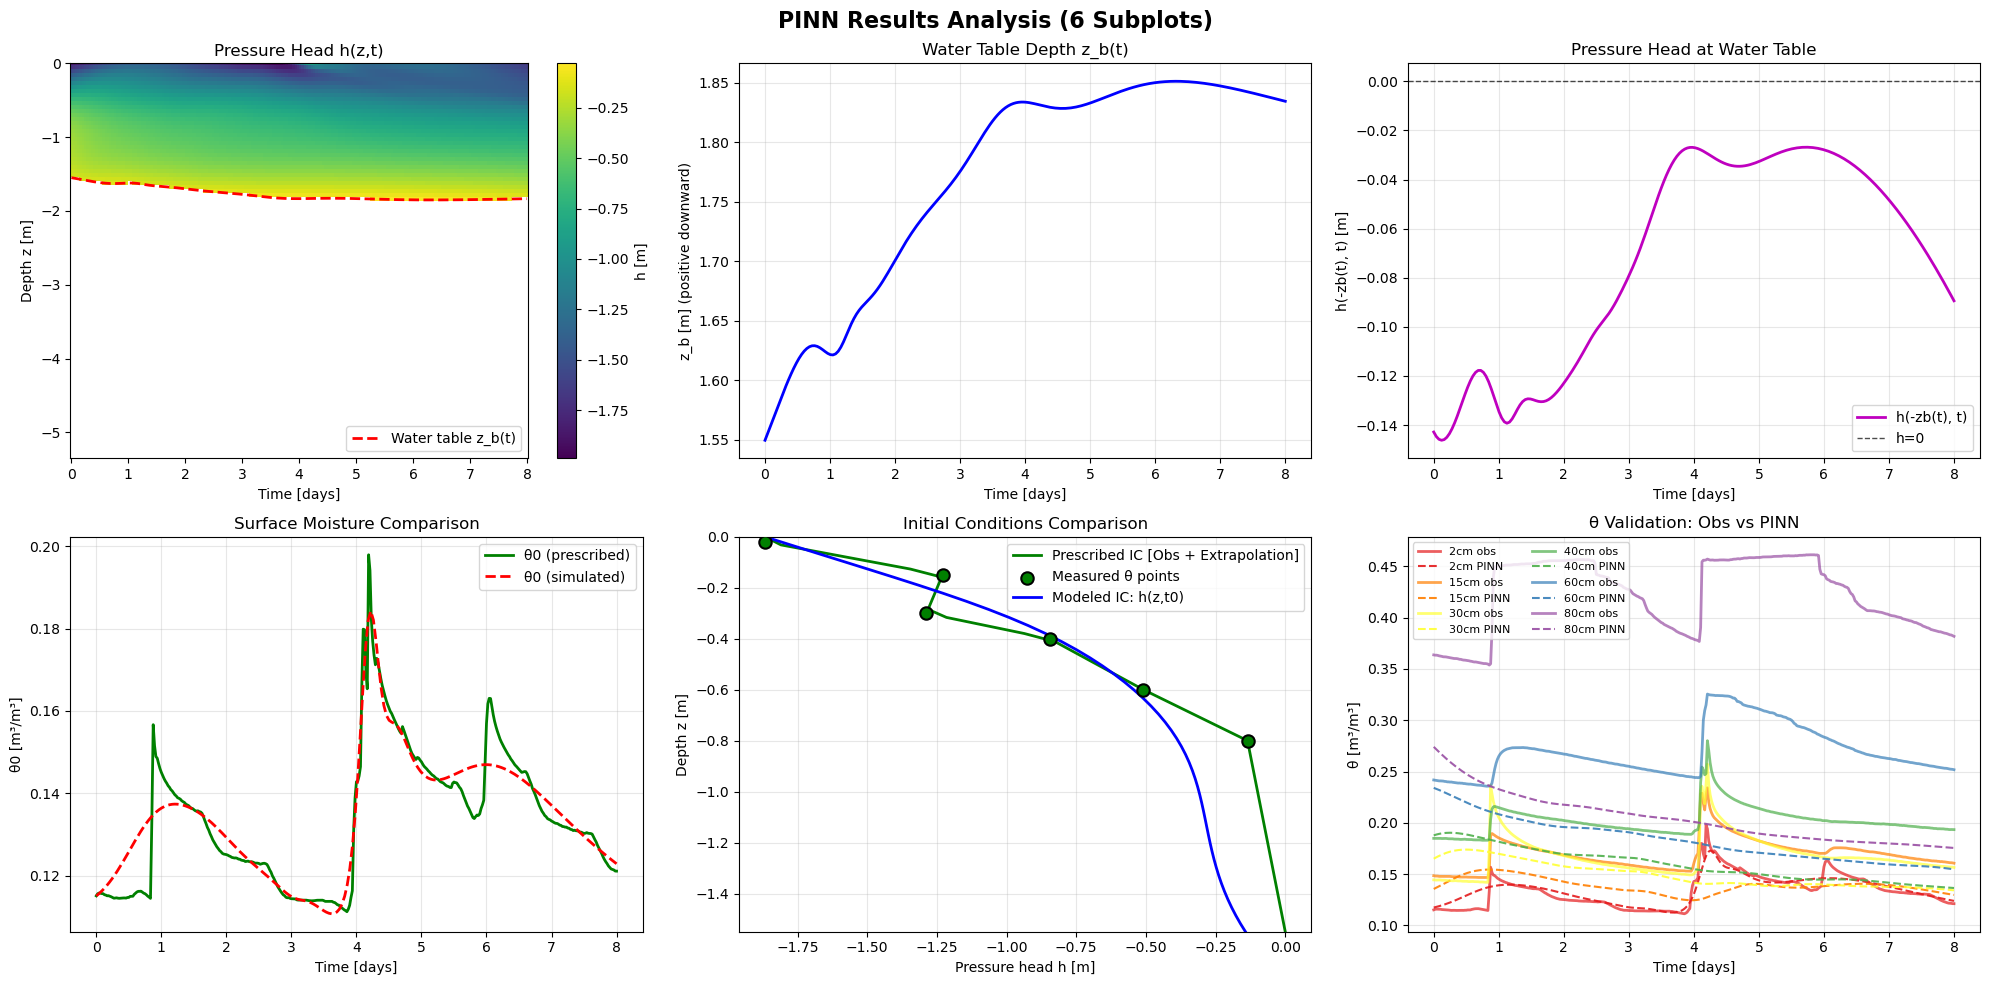


Summary Statistics:
Water table depth range: 1.550 to 1.851 m
Surface head range: -1.988 to -0.850 m
h(-zb(t), t) range: -0.146186 to -0.026852 m
Max |h(-zb(t), t)|: 0.146186 m (should be close to 0)
Max IC error: 0.241465 m

Theta Validation Statistics:
    2cm: RMSE = 0.006813 m³/m³, MAE = 0.004620 m³/m³
   15cm: RMSE = 0.034996 m³/m³, MAE = 0.031155 m³/m³
   30cm: RMSE = 0.031004 m³/m³, MAE = 0.025011 m³/m³
   40cm: RMSE = 0.048869 m³/m³, MAE = 0.043683 m³/m³
   60cm: RMSE = 0.094590 m³/m³, MAE = 0.086670 m³/m³
   80cm: RMSE = 0.223858 m³/m³, MAE = 0.218828 m³/m³


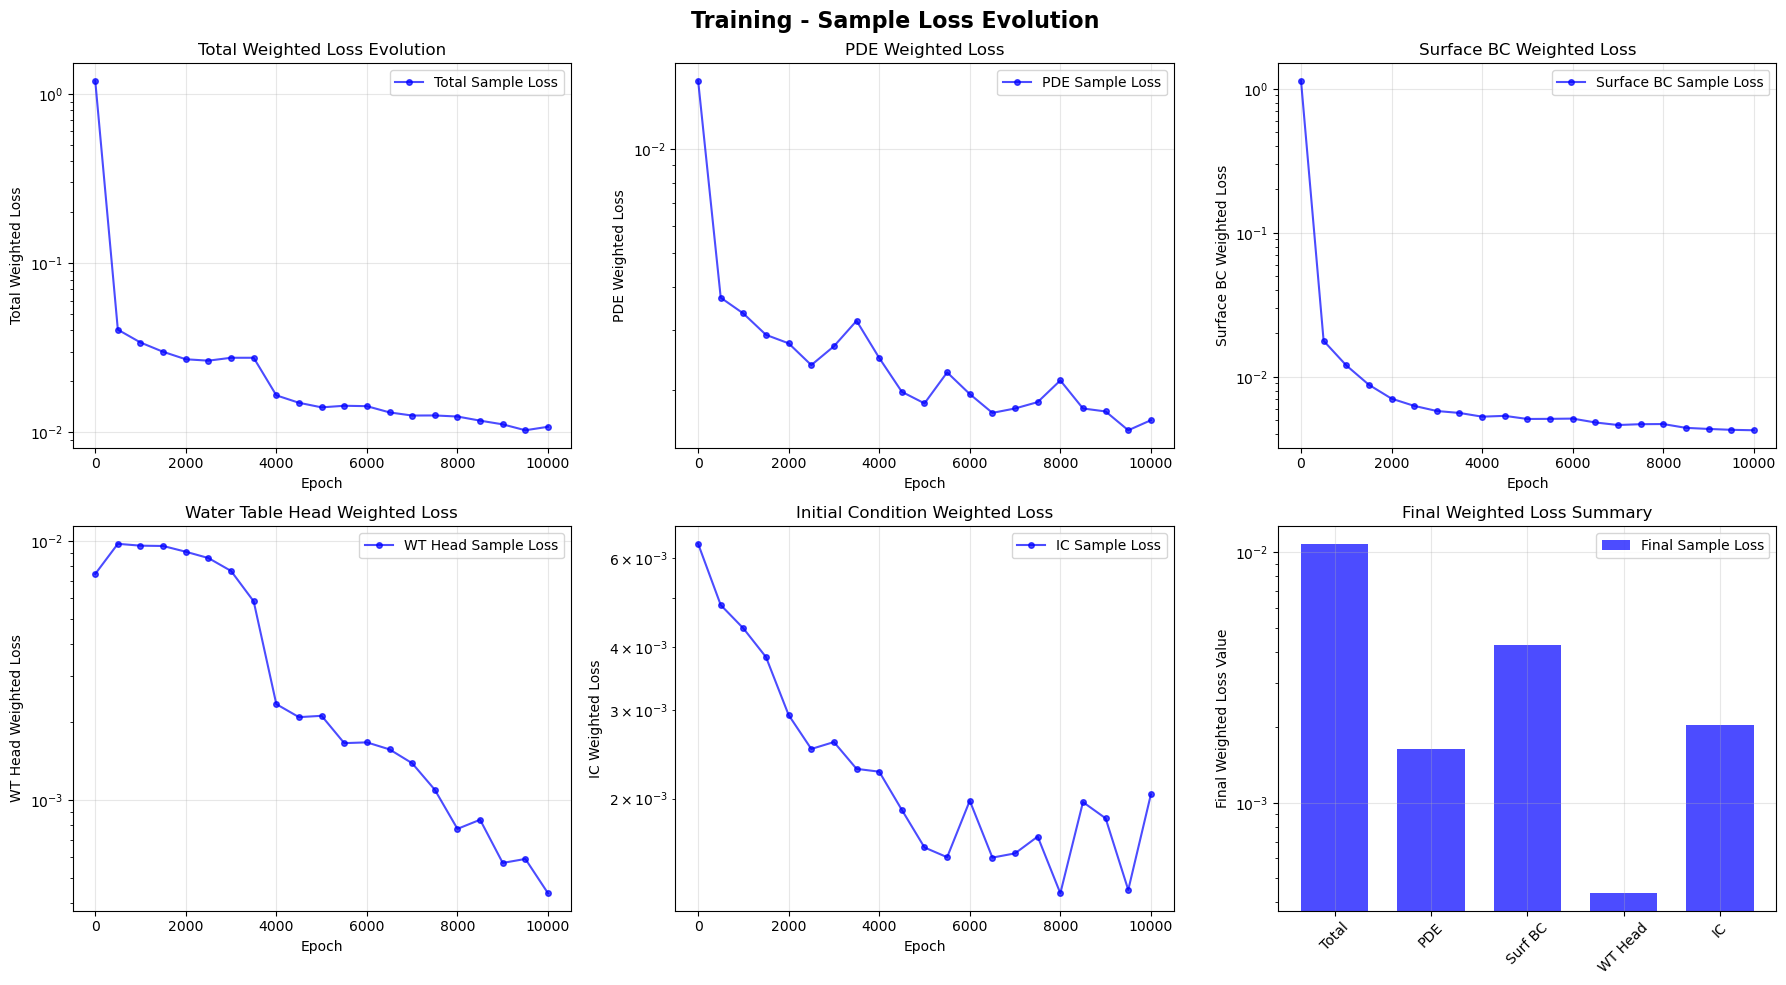

In [20]:
# ============================================================================
# VISUALIZE FINE-TUNED MODEL
# ============================================================================

# Load soil parameters from checkpoint (must match base training)
checkpoint = torch.load(BASE_CHECKPOINT, map_location=device)
soil_params = checkpoint['normalization_params']['soil_params']

print("="*70)
print("SOIL PARAMETERS (from base checkpoint):")
print("="*70)
for key, val in soil_params.items():
    print(f"  {key}: {val}")
print("="*70)

# Prepare observation data for validation
obs_data_viz = {
    'times': times_seconds,
    'depths': [-0.02, -0.15, -0.30, -0.40, -0.60, -0.80],  # Negative (below surface)
    'theta': [theta_2cm, theta_15cm, theta_30cm, theta_40cm, theta_60cm, theta_80cm]
}

# Plot comprehensive results
model.eval()
plot_comprehensive_results(
    model, 
    new_theta0_data, 
    soil_params, 
    device=device, 
    obs_data=obs_data_viz
)


# ============================================================================
# PLOT TRAINING LOSSES
# ============================================================================

plot_training_losses(losses, comps, sample_losses, sample_comps, sample_epochs)

## 6. Save Fine-Tuned Model

In [21]:
# ============================================================================
# SAVE FINE-TUNED MODEL (Optional)
# ============================================================================

# The model is automatically saved to checkpoints_finetune/ during training
# You can also manually save the final model here if needed

import datetime

output_path = f'checkpoints_finetune/finetuned_{START_DATE}_to_{END_DATE}.pt'

# Save checkpoint with metadata
checkpoint_save = {
    'model_state_dict': model.state_dict() if not hasattr(model, 'module') else model.module.state_dict(),
    'epoch': 10000,
    'base_checkpoint': BASE_CHECKPOINT,
    'finetune_period': f'{START_DATE} to {END_DATE}',
    'timestamp': datetime.datetime.now().isoformat(),
}

torch.save(checkpoint_save, output_path)
print(f"✓ Fine-tuned model saved to: {output_path}")

✓ Fine-tuned model saved to: checkpoints_finetune/finetuned_2017-05-01_to_2017-05-9.pt


## Summary

**What was preserved from base model:**
- ✅ Network weights (pre-trained h_net and zb_net)
- ✅ Soil parameters (θs, θr, α, n, Ks, l)
- ✅ Normalization parameters (L, S_max, Sy, zr)
- ✅ Network scaling (t_ref_tilde, z_max_tilde)

**What was changed:**
- ❌ Boundary condition data (NEW time period)
- ❌ Learning rate (1e-4 vs 5e-4)
- ❌ Number of epochs (10k vs 50k)
- ❌ Weight updates (fixed vs adaptive)

**Key Points:**
- Fine-tuning uses **Dirichlet BC** with soil moisture θ(z=0,t)
- Lower learning rate prevents catastrophic forgetting
- Gradient-based sampling adapts to new BC gradient patterns
- All physics parameters preserved for consistency